# Real-time REM detection on the Walch (2019) data

A walk-through of the pipeline on the dataset, using the project modules
(`dataset`, `features`, `module`, `splits`, `evaluate`):

1. the raw wearable signals and PSG labels,
2. the causal features,
3. the real-time (look-ahead) check,
4. leave-one-subject-out evaluation,
5. the baseline REM detector,
6. a tuned XGBoost.

Feature extraction lives in `features.py`; `module.py` holds the model.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

import features, splits
from dataset import load_records, REM
from module import build_model

records = load_records()
n_scored = sum(int(r.scored_mask.sum()) for r in records)
n_rem = sum(int((r.stage == REM).sum()) for r in records)
print(f"{len(records)} subjects | {n_scored} scored 30s epochs | "
      f"REM prevalence {100 * n_rem / n_scored:.1f}%")

def rem_spans(r):
    '''Contiguous REM intervals (in hours) for shading plots.'''
    flag = (r.stage == REM).astype(int)
    d = np.diff(flag, prepend=0, append=0)
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    h = r.epoch_time / 3600
    return [(h[s], h[min(e, len(h) - 1)]) for s, e in zip(starts, ends)]

['/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/4426783_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/5498603_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/1455390_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/7749105_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/8692923_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/8258170_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/1360686_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/781756_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/8686948_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/759667_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/walch2019/2598705_labeled_sleep.txt', '/Users/mustaf/Desktop

31 subjects | 26773 scored 30s epochs | REM prevalence 22.0%


## 1. The data

Each subject is one night: heart rate (~0.2 Hz) and triaxial accelerometer
(~30 Hz) from an Apple Watch, with a polysomnography hypnogram at 30 s resolution.
One subject's raw streams, REM periods shaded.

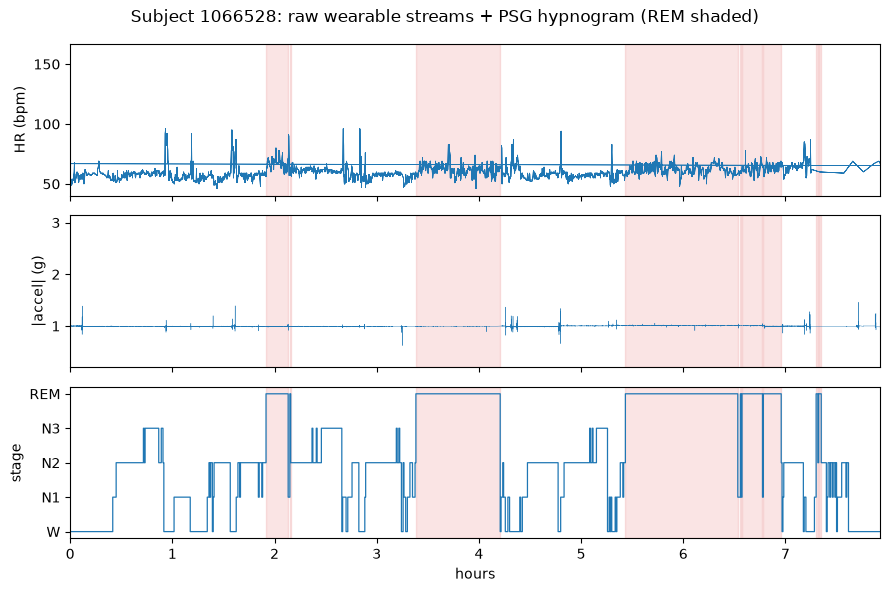

In [2]:
r = records[0]
mag = np.linalg.norm(r.motion, axis=1)
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
ax[0].plot(r.hr_time / 3600, r.hr, lw=0.5); ax[0].set_ylabel("HR (bpm)")
ax[0].set_xlim(0, r.epoch_time.max() / 3600)
ax[1].plot(r.motion_time[::50] / 3600, mag[::50], lw=0.3); ax[1].set_ylabel("|accel| (g)")
ax[2].step(r.epoch_time / 3600, r.stage, where="post", lw=0.9)
ax[2].set_yticks([0, 1, 2, 3, 4]); ax[2].set_yticklabels(["W", "N1", "N2", "N3", "REM"])
ax[2].set_ylabel("stage"); ax[2].set_xlabel("hours")
for a in ax:
    for s, e in rem_spans(r): a.axvspan(s, e, color="tab:red", alpha=0.12)
fig.suptitle(f"Subject {r.subject_id}: raw wearable streams + PSG hypnogram (REM shaded)")
plt.tight_layout(); plt.show()

## 2. Features

`features.featurize` turns the raw streams into one row per epoch. The first three
columns are the paper's base features -- smoothed heart rate, ActiGraph activity
counts (via `agcounts`), and time-of-night -- and the rest are causal *temporal*
features over HR and activity: the rate of change, and rolling means / standard
deviations over ~5 and ~15 min windows (REM shows elevated, variable HR with
near-still motion). Every column uses only samples at or before the end of its
epoch. The column order and each feature's on-device state are documented in
`features.FEATURE_NAMES` and the deployment-state contract at the top of
`features.py`.

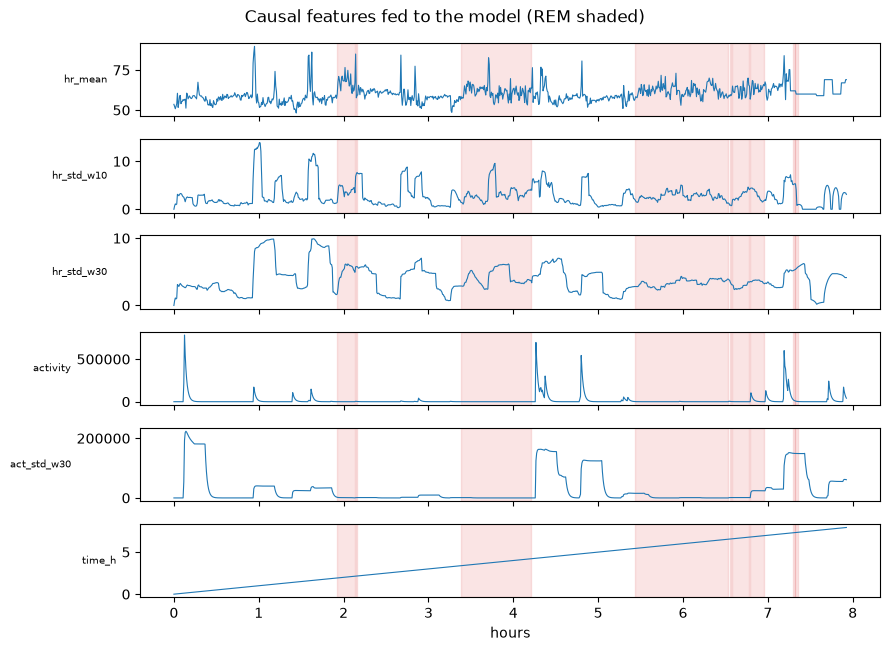

feature matrix shape (epochs x features): (952, 6)
columns: ['hr_mean', 'hr_std_w10', 'hr_std_w30', 'activity', 'act_std_w30', 'time_h']


In [3]:
X_one = features.featurize(r)
names = features.FEATURE_NAMES
fig, ax = plt.subplots(len(names), 1, figsize=(9, 1.1 * len(names)), sharex=True)
for k, name in enumerate(names):
    ax[k].plot(r.epoch_time / 3600, X_one[:, k], lw=0.8)
    ax[k].set_ylabel(name, fontsize=7, rotation=0, ha="right", va="center")
    for s, e in rem_spans(r): ax[k].axvspan(s, e, color="tab:red", alpha=0.12)
ax[-1].set_xlabel("hours")
fig.suptitle("Causal features fed to the model (REM shaded)")
plt.tight_layout(); plt.show()
print(f"feature matrix shape (epochs x features): {X_one.shape}")
print("columns:", names)

## 3. Real-time (look-ahead) check

A live watch scores each epoch using only data up to that moment. `evaluate.py`
checks this every fold with `_predictions_are_causal`: at several cut points the
first-k predictions must be unchanged when later epochs are removed and when their
content is altered. Below, a causal model passes and a model that reads one epoch
ahead does not.

In [4]:
from evaluate import _predictions_are_causal

X, y, groups = splits.make_dataset(records)     # fixed causal features for every epoch
train_idx, test_idx = next(splits.cross_validator().split(X, y, groups=groups))
model = build_model().fit(X[train_idx], y[train_idx])
X_test = X[test_idx]
print("real-time (causal) model passes the guard :",
      _predictions_are_causal(model, X_test, model.predict(X_test)))

class LookAheadModel:               # cheats: labels epoch i using epoch i+1
    def predict(self, Xa):
        nxt = np.r_[Xa[1:, 0], Xa[-1, 0]]
        return (nxt > 0.5).astype(int)

cheat = LookAheadModel()
print("look-ahead (cheating) model passes the guard:",
      _predictions_are_causal(cheat, X_test, cheat.predict(X_test)))

/Users/mustaf/Desktop/realtime-rem-detection/.venv/lib/python3.12/site-packages/agcounts/extract.py:347: RuntimeWarning: invalid value encountered in cast
  return counts.astype(int)


real-time (causal) model passes the guard : True
look-ahead (cheating) model passes the guard: False


## 4. Leave-one-subject-out

Epochs from one sleeper are correlated, so testing on a subject you trained on
inflates the score. `splits` groups epochs by subject and uses scikit-learn's
`LeaveOneGroupOut`: each subject is the test set once and never appears in its own
training fold.

In [5]:
cv = splits.cross_validator()
n_folds = cv.get_n_splits(groups=groups)
disjoint = all(set(groups[tr]).isdisjoint(set(groups[te])) for tr, te in cv.split(X, y, groups=groups))
print(f"{n_folds} folds | every subject held out once | train/test subject-disjoint: {disjoint}")
print(f"feature matrix: {X.shape[0]} epochs x {X.shape[1]} fixed features")

31 folds | every subject held out once | train/test subject-disjoint: True
feature matrix: 26773 epochs x 6 fixed features


## 5. Baseline: binary REM detection

The task is REM vs not-REM. We report the REM F-beta(0.3) that Weco maximizes, plus
precision and recall and the 2-class confusion, under leave-one-subject-out. This
uses `build_model()` from `module.py` -- exactly the estimator the harness scores.

REM: F-beta(0.3) = 0.5134 +/- 0.0358 SEM | precision 0.594  recall 0.277  (per-subject mean over 30 folds)
              precision    recall  f1-score   support

     not-REM       0.83      0.94      0.88     20889
         REM       0.59      0.30      0.39      5884

    accuracy                           0.80     26773
   macro avg       0.71      0.62      0.64     26773
weighted avg       0.77      0.80      0.77     26773



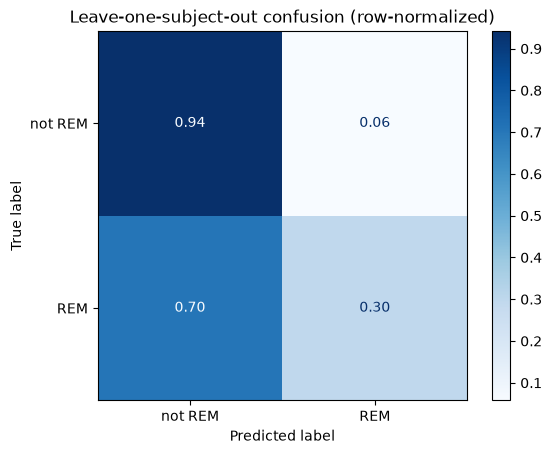

In [6]:
from sklearn.metrics import (fbeta_score, precision_score, recall_score,
                             classification_report, ConfusionMatrixDisplay)

BETA = 0.3
fb, pr, rc, yt_all, yp_all = [], [], [], [], []
for tr, te in splits.cross_validator().split(X, y, groups=groups):
    m = build_model().fit(X[tr], y[tr])
    yp, yt = m.predict(X[te]), y[te]
    yt_all.append(yt); yp_all.append(yp)
    if (yt == 1).sum() == 0:
        continue
    fb.append(fbeta_score(yt, yp, beta=BETA, pos_label=1, zero_division=0))
    pr.append(precision_score(yt, yp, pos_label=1, zero_division=0))
    rc.append(recall_score(yt, yp, pos_label=1, zero_division=0))

fb = np.array(fb)
print(f"REM: F-beta(0.3) = {fb.mean():.4f} +/- {fb.std(ddof=1)/np.sqrt(fb.size):.4f} SEM "
      f"| precision {np.mean(pr):.3f}  recall {np.mean(rc):.3f}  (per-subject mean over {fb.size} folds)")

yt_all, yp_all = np.concatenate(yt_all), np.concatenate(yp_all)
print(classification_report(yt_all, yp_all, labels=[0, 1], target_names=["not-REM", "REM"], zero_division=0))
ConfusionMatrixDisplay.from_predictions(yt_all, yp_all, display_labels=["not REM", "REM"],
                                        normalize="true", cmap="Blues", values_format=".2f")
plt.title("Leave-one-subject-out confusion (row-normalized)"); plt.show()

## 6. Tuned XGBoost with a motor-atonia prior

An XGBoost REM detector with two things baked in: **monotone constraints** encoding
motor atonia -- the activity columns (`activity`, `act_std_w30`) can only *lower*
P(REM), since REM has near-still motion -- and **hyperparameters tuned by successive
halving** (`HalvingRandomSearchCV`), scored by best-threshold REM F-beta(0.3). Scored
under leave-one-subject-out with the decision threshold tuned per training split. The
atonia prior + threshold together are the strongest REM-precision lever we found.

In [7]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV, GroupKFold
from sklearn.metrics import make_scorer
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier

# motor-atonia prior: activity columns can only DECREASE P(REM)
ATONIA = ("activity", "act_std_w30")
MONO = "(" + ",".join("-1" if n in ATONIA else "0" for n in features.FEATURE_NAMES) + ")"

def _best_fbeta(y_true, proba):                       # threshold-free HPO score
    p = proba[:, 1] if getattr(proba, "ndim", 1) == 2 else proba
    return max(fbeta_score(y_true, (p >= t).astype(int), beta=BETA, pos_label=1, zero_division=0)
               for t in np.linspace(0.05, 0.95, 37))
scorer = make_scorer(_best_fbeta, response_method="predict_proba")

neg, pos = int((y == 0).sum()), int((y == 1).sum())
fixed = dict(tree_method="hist", n_jobs=-1, random_state=42, monotone_constraints=MONO)
space = dict(n_estimators=randint(150, 400), max_depth=randint(3, 7),
             learning_rate=loguniform(0.02, 0.2), min_child_weight=randint(1, 8),
             subsample=uniform(0.6, 0.4), colsample_bytree=uniform(0.6, 0.4),
             reg_lambda=loguniform(0.5, 10.0))
base = XGBClassifier(scale_pos_weight=neg / pos, **fixed)
best = HalvingRandomSearchCV(base, space, n_candidates=20, factor=3, scoring=scorer,
                             cv=GroupKFold(3), random_state=42, n_jobs=1).fit(X, y, groups=groups).best_params_
print("tuned params:", {k: (round(v, 4) if isinstance(v, float) else int(v)) for k, v in best.items()})

fb, pr, rc = [], [], []
for tr, te in splits.cross_validator().split(X, y, groups=groups):
    spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
    m = XGBClassifier(**best, scale_pos_weight=spw, **fixed).fit(X[tr], y[tr])
    p_tr = m.predict_proba(X[tr])[:, 1]                # tune the decision threshold on TRAIN
    tau = float(max(np.linspace(0.05, 0.95, 181),
        key=lambda t: fbeta_score(y[tr], (p_tr >= t).astype(int), beta=BETA, pos_label=1, zero_division=0)))
    yp, yt = (m.predict_proba(X[te])[:, 1] >= tau).astype(int), y[te]
    if (yt == 1).sum() == 0:
        continue
    fb.append(fbeta_score(yt, yp, beta=BETA, pos_label=1, zero_division=0))
    pr.append(precision_score(yt, yp, pos_label=1, zero_division=0))
    rc.append(recall_score(yt, yp, pos_label=1, zero_division=0))

fb = np.array(fb)
print(f"atonia-monotone tuned XGBoost: REM F-beta(0.3) = {fb.mean():.4f} +/- "
      f"{fb.std(ddof=1)/np.sqrt(fb.size):.4f} SEM | precision {np.mean(pr):.3f}  recall {np.mean(rc):.3f}")

tuned params: {'colsample_bytree': np.float64(0.6795), 'learning_rate': np.float64(0.1029), 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 272, 'reg_lambda': np.float64(0.6242), 'subsample': np.float64(0.7434)}


atonia-monotone tuned XGBoost: REM F-beta(0.3) = 0.5071 +/- 0.0383 SEM | precision 0.602  recall 0.263


## Summary

The pipeline runs end to end: wearable and PSG signals, the fixed causal features, a
look-ahead check, and a per-subject leave-one-subject-out score. The task is binary
REM vs not-REM, scored by precision-weighted REM F-beta(0.3). `weco run` rewrites the
model in `module.py` (the features in `features.py` stay fixed) to raise that score,
and the look-ahead check keeps every candidate deployable in real time.